사용 장치: cuda
Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

AutoEncoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
  )
)
[Epoch 1/10] Train Loss: 0.059152 | Test Loss: 0.034819
[Epoch 2/10] Train Loss: 0.030283 | Test Loss: 0.026640
[Epoch 3/10] Train Loss: 0.025212 | Test Loss: 0.022973
[Epoch 4/10] Train Loss: 0.021762 | Test Loss: 0.020040
[Epoch 5/10] Train Loss: 0.019229 | Test Loss: 0.017871
[Epoch 6/10] Train Loss: 0.017552 | Test Loss: 0.016520
[Epoch 7/10] Train Loss: 

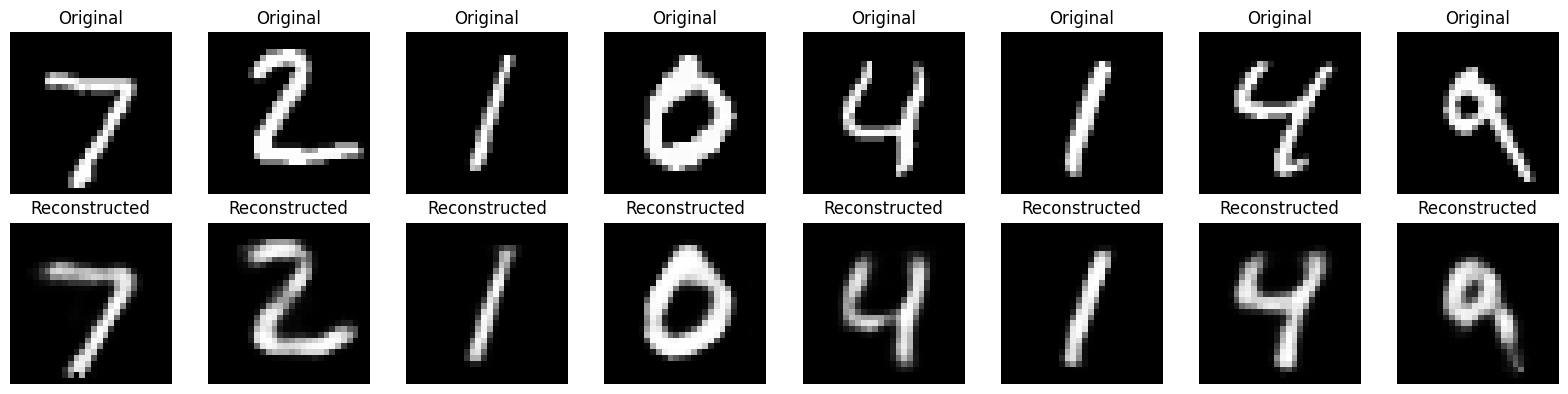

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =========================================
# 1. device 설정
# =========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)

# =========================================
# 2. 하이퍼파라미터
# =========================================
batch_size = 128
learning_rate = 1e-3
epochs = 10
latent_dim = 32  # bottleneck 크기

# =========================================
# 3. 데이터셋 준비 (MNIST)
# =========================================
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# =========================================
# 4. AutoEncoder 모델 정의
# =========================================
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),              # (1, 28, 28) -> (784,)
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)  # bottleneck
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()               # 픽셀 값을 0~1로 맞춤
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        x_hat = x_hat.view(-1, 1, 28, 28)  # 다시 이미지 모양으로 변환
        return x_hat

model = AutoEncoder(latent_dim=latent_dim).to(device)
print(model)

# =========================================
# 5. 손실함수 / 옵티마이저
# =========================================
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# =========================================
# 6. 학습 함수
# =========================================
def train(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, _ in loader:
        images = images.to(device)

        # forward
        outputs = model(images)
        loss = criterion(outputs, images)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

# =========================================
# 7. 평가 함수
# =========================================
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            running_loss += loss.item()

    return running_loss / len(loader)

# =========================================
# 8. 학습 루프
# =========================================
for epoch in range(epochs):
    train_loss = train(model, train_loader, criterion, optimizer, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    print(f"[Epoch {epoch+1}/{epochs}] Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")

# =========================================
# 9. 복원 결과 시각화
# =========================================
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)

    reconstructed = model(images)

# CPU로 이동
images = images.cpu()
reconstructed = reconstructed.cpu()

# 원본 8개 / 복원 8개 출력
n = 8
plt.figure(figsize=(16, 4))

for i in range(n):
    # 원본
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # 복원
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 이상탐지

device: cuda
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

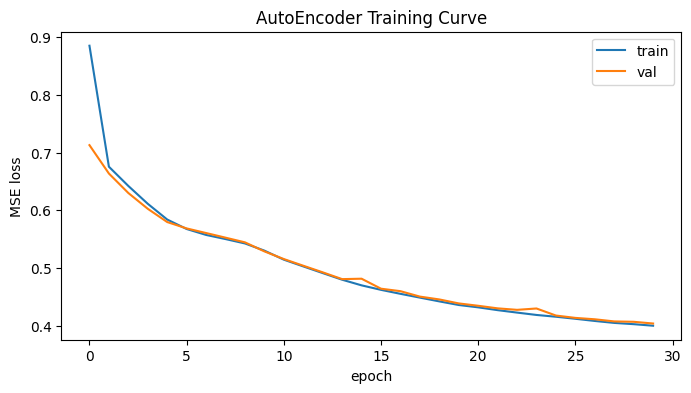

threshold (95th percentile of normal val errors): 0.9622648


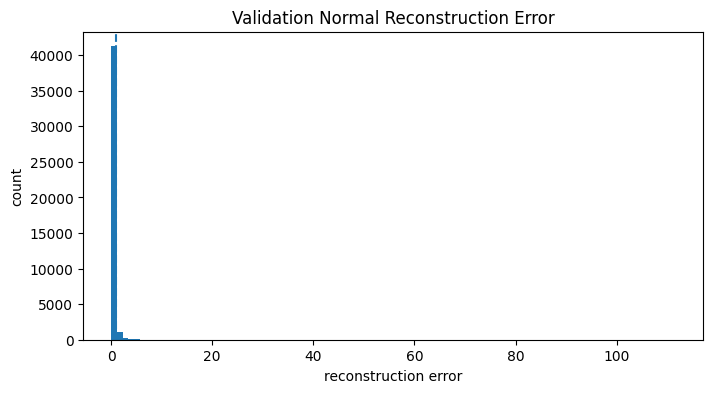

Confusion Matrix
[[40534  2114]
 [   11    63]]

Classification Report
              precision    recall  f1-score   support

           0     0.9997    0.9504    0.9745     42648
           1     0.0289    0.8514    0.0560        74

    accuracy                         0.9503     42722
   macro avg     0.5143    0.9009    0.5152     42722
weighted avg     0.9980    0.9503    0.9729     42722

ROC-AUC (using reconstruction error score): 0.950893
PR-AUC  (using reconstruction error score): 0.498435


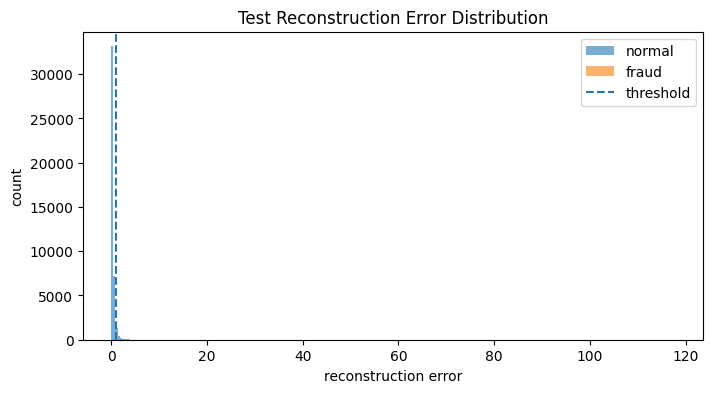

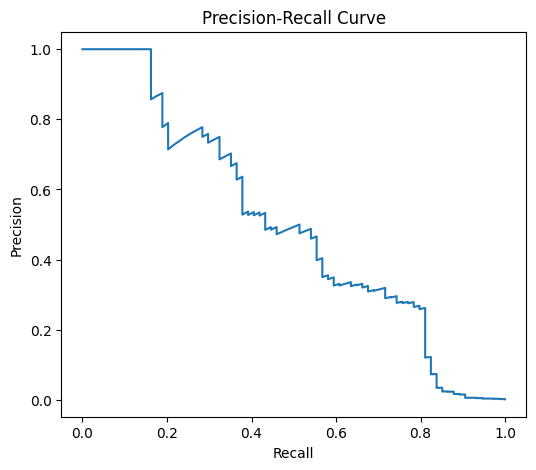


Top 20 highest reconstruction errors:
       reconstruction_error  true_label  pred_label
6114             117.772697           1           1
15950             85.525856           1           1
5649              79.765228           1           1
20271             74.929955           1           1
22073             63.076447           1           1
8563              60.288387           1           1
5078              59.291294           1           1
805               59.259071           1           1
32967             58.422329           1           1
26257             58.349163           1           1
33718             58.315052           1           1
26081             57.989983           1           1
10578             43.333912           0           1
7763              42.431858           0           1
10535             40.599369           1           1
6936              40.213482           1           1
19372             40.193428           0           1
16114             40.0526

In [3]:
# =========================
# 0. 라이브러리
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)
import matplotlib.pyplot as plt

# 재현성
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# =========================
# 1. 데이터 로드
# =========================
# Kaggle에서 받은 creditcard.csv 경로
df = pd.read_csv("creditcard.csv")

print(df.head())
print(df["Class"].value_counts())
print(df.shape)

# =========================
# 2. 전처리
# =========================
# Feature / Label 분리
X = df.drop(columns=["Class"]).copy()
y = df["Class"].copy()

# Amount, Time은 스케일 차이가 커서 따로 정규화
# (V1~V28은 이미 PCA 변환된 익명 피처라 비교적 스케일이 정리되어 있음)
scaler = StandardScaler()
X[["Time", "Amount"]] = scaler.fit_transform(X[["Time", "Amount"]])

# train / temp 분리
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

# validation / test 분리
X_val_full, X_test, y_val_full, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

# =========================
# 3. AutoEncoder 학습용 데이터 구성
#    핵심: 정상 데이터만 학습에 사용
# =========================
X_train_normal = X_train_full[y_train_full == 0]
X_val_normal = X_val_full[y_val_full == 0]

print("Train full:", X_train_full.shape)
print("Train normal only:", X_train_normal.shape)
print("Val normal only:", X_val_normal.shape)
print("Test mixed:", X_test.shape)
print("Fraud ratio in test:", y_test.mean())

# numpy -> tensor
X_train_tensor = torch.tensor(X_train_normal.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_normal.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=512, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor), batch_size=512, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=512, shuffle=False)

input_dim = X.shape[1]
print("input_dim =", input_dim)

# =========================
# 4. AutoEncoder 모델 정의
# =========================
class AutoEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 22),
            nn.ReLU(),
            nn.Linear(22, 12),
            nn.ReLU(),
            nn.Linear(12, 8),
            nn.ReLU(),
            nn.Linear(8, 4)
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 12),
            nn.ReLU(),
            nn.Linear(12, 22),
            nn.ReLU(),
            nn.Linear(22, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

model = AutoEncoder(input_dim).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# =========================
# 5. 학습 / 검증 함수
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for (x,) in loader:
        x = x.to(device)

        x_hat = model(x)
        loss = criterion(x_hat, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for (x,) in loader:
        x = x.to(device)
        x_hat = model(x)
        loss = criterion(x_hat, x)
        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)

# =========================
# 6. 학습
# =========================
epochs = 30
train_losses = []
val_losses = []

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = eval_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"[{epoch:02d}/{epochs}] train_loss={train_loss:.6f}, val_loss={val_loss:.6f}")

# 학습 곡선
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.title("AutoEncoder Training Curve")
plt.show()

# =========================
# 7. 샘플별 reconstruction error 계산 함수
# =========================
@torch.no_grad()
def get_reconstruction_errors(model, x_tensor, device):
    model.eval()
    x_tensor = x_tensor.to(device)
    x_hat = model(x_tensor)
    errors = torch.mean((x_tensor - x_hat) ** 2, dim=1)
    return errors.detach().cpu().numpy()

# 정상 validation 데이터의 오차 분포
val_errors = get_reconstruction_errors(model, X_val_tensor, device)

# threshold 설정
# 예: 정상 validation 오차의 95퍼센타일
threshold = np.percentile(val_errors, 95)
print("threshold (95th percentile of normal val errors):", threshold)

plt.figure(figsize=(8, 4))
plt.hist(val_errors, bins=100)
plt.axvline(threshold, linestyle="--")
plt.title("Validation Normal Reconstruction Error")
plt.xlabel("reconstruction error")
plt.ylabel("count")
plt.show()

# =========================
# 8. 테스트셋 평가
# =========================
test_errors = get_reconstruction_errors(model, X_test_tensor, device)
y_pred = (test_errors > threshold).astype(int)

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred, digits=4))

# ranking metric
roc_auc = roc_auc_score(y_test, test_errors)
pr_auc = average_precision_score(y_test, test_errors)

print(f"ROC-AUC (using reconstruction error score): {roc_auc:.6f}")
print(f"PR-AUC  (using reconstruction error score): {pr_auc:.6f}")

# 테스트셋 오류 분포 시각화
plt.figure(figsize=(8, 4))
plt.hist(test_errors[y_test.values == 0], bins=100, alpha=0.6, label="normal")
plt.hist(test_errors[y_test.values == 1], bins=100, alpha=0.6, label="fraud")
plt.axvline(threshold, linestyle="--", label="threshold")
plt.xlabel("reconstruction error")
plt.ylabel("count")
plt.title("Test Reconstruction Error Distribution")
plt.legend()
plt.show()

# =========================
# 9. threshold를 바꿔가며 보고 싶을 때
# =========================
precisions, recalls, thresholds = precision_recall_curve(y_test, test_errors)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# =========================
# 10. 임의 샘플 몇 개 확인
# =========================
results = pd.DataFrame({
    "reconstruction_error": test_errors,
    "true_label": y_test.values,
    "pred_label": y_pred
}).sort_values("reconstruction_error", ascending=False)

print("\nTop 20 highest reconstruction errors:")
print(results.head(20))

# 노이즈 제거

Epoch [1/10] Loss: 0.074994
Epoch [2/10] Loss: 0.015454
Epoch [3/10] Loss: 0.014522
Epoch [4/10] Loss: 0.014124
Epoch [5/10] Loss: 0.013830
Epoch [6/10] Loss: 0.013589
Epoch [7/10] Loss: 0.013377
Epoch [8/10] Loss: 0.013209
Epoch [9/10] Loss: 0.013080
Epoch [10/10] Loss: 0.012982


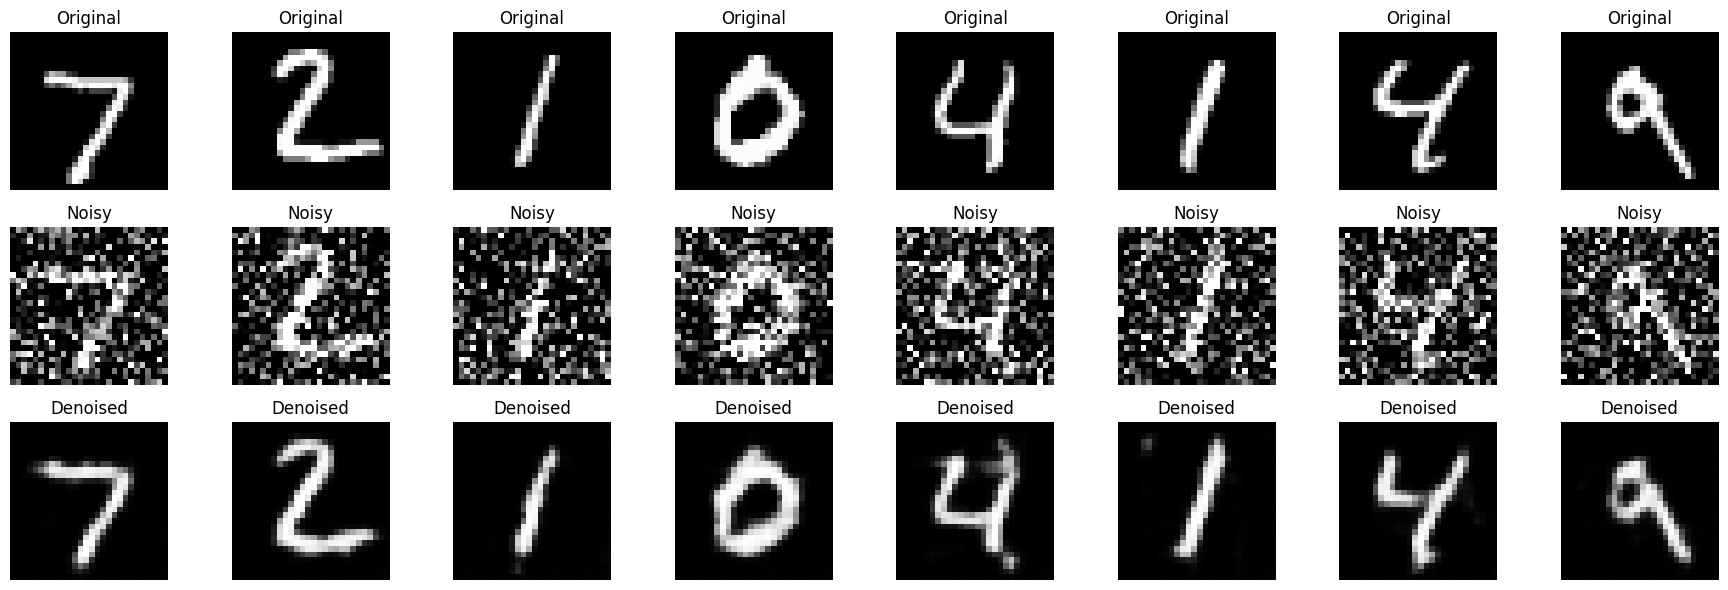

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =========================
# 1. device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# 2. 하이퍼파라미터
# =========================
batch_size = 128
lr = 1e-3
epochs = 10

# =========================
# 3. 데이터
# =========================
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# =========================
# 4. 노이즈 함수
# =========================
def add_noise(x, noise_factor=0.5):
    noise = torch.randn_like(x) * noise_factor
    x_noisy = x + noise
    return torch.clamp(x_noisy, 0., 1.)

# =========================
# 5. 모델 (CNN AutoEncoder)
# =========================
class DenoisingAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 28 → 14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 14 → 7
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # 7 → 14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),  # 14 → 28
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

model = DenoisingAE().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# =========================
# 6. 학습
# =========================
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)
        noisy_images = add_noise(images)

        outputs = model(noisy_images)
        loss = criterion(outputs, images)  # 🔥 핵심

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(train_loader):.6f}")

# =========================
# 7. 테스트 시각화
# =========================
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    noisy_images = add_noise(images)

    outputs = model(noisy_images)

# CPU로 이동
images = images.cpu()
noisy_images = noisy_images.cpu()
outputs = outputs.cpu()

# =========================
# 8. 결과 출력
# =========================
n = 8
plt.figure(figsize=(18, 6))

for i in range(n):
    # 원본
    plt.subplot(3, n, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # 노이즈
    plt.subplot(3, n, i+n+1)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # 복원
    plt.subplot(3, n, i+2*n+1)
    plt.imshow(outputs[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()